# Seminar 5

## Team members

Ana Enrech (284144) | Manel Gutierrez (286144) | Andrea Ochaita (284169)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#imports
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import copy
import os
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

# **Part 1: ML model definition**

In this model, the input is a flattened CSI matrix 30x3x3 = 270 features, and the output is a set of logits for 12 pose classes.

The network has three hidden layers. Batch normalization and dropout are applied after the first two layers to stabilize training and reduce overfitting. ReLU activations introduce non-linearity.


In [ ]:
INPUT_DIM   = 270   #Flattened CSI matrix: 30 × 3 × 3
NUM_CLASSES = 12    #Poses: [1-12]

class PoseClassifier(nn.Module):
    """
    MLP for Wi-Fi CSI pose classification.
    Input  : 270-dimensional flattened CSI vector
    Output : 12-class logits
    """
    def __init__(self, input_dim=INPUT_DIM, num_classes=NUM_CLASSES):
        super(PoseClassifier, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        return self.net(x)

# Sanity check
_model = PoseClassifier()
print(f"Model output shape: {_model(torch.randn(4, INPUT_DIM)).shape}")

Model output shape: torch.Size([4, 12])


# **PART 2: Preparation of the FL setting**

The dataset is split across 10 clients, each holding a local subset of samples. Labels are originally in the range [1–12] and are shifted to [0–11].

As seen in the output, the data distribution is highly non-IID: each client only has between 2 and 8 of the 12 possible classes, and dataset sizes vary significantly (from 64 to 448 samples). This heterogeneity is one of the main challenges in Federated Learning, as each local model will be biased towards the classes present in its own data.

Load data:

In [ ]:
#load clients dataset

base_path = '/content/drive/MyDrive/AAX/seminar 5/dataset/'

#cargamos los 10 clientes: features y labels
#convertimos los índices de [1-12] a [0-11]
X_client_1  = pd.read_csv(base_path + 'client_datasets/client_1_features.csv',  header=None).values.astype('float32')
y_client_1  = pd.read_csv(base_path + 'client_datasets/client_1_labels.csv',    header=None).values.flatten() - 1

X_client_2  = pd.read_csv(base_path + 'client_datasets/client_2_features.csv',  header=None).values.astype('float32')
y_client_2  = pd.read_csv(base_path + 'client_datasets/client_2_labels.csv',    header=None).values.flatten() - 1

X_client_3  = pd.read_csv(base_path + 'client_datasets/client_3_features.csv',  header=None).values.astype('float32')
y_client_3  = pd.read_csv(base_path + 'client_datasets/client_3_labels.csv',    header=None).values.flatten() - 1

X_client_4  = pd.read_csv(base_path + 'client_datasets/client_4_features.csv',  header=None).values.astype('float32')
y_client_4  = pd.read_csv(base_path + 'client_datasets/client_4_labels.csv',    header=None).values.flatten() - 1

X_client_5  = pd.read_csv(base_path + 'client_datasets/client_5_features.csv',  header=None).values.astype('float32')
y_client_5  = pd.read_csv(base_path + 'client_datasets/client_5_labels.csv',    header=None).values.flatten() - 1

X_client_6  = pd.read_csv(base_path + 'client_datasets/client_6_features.csv',  header=None).values.astype('float32')
y_client_6  = pd.read_csv(base_path + 'client_datasets/client_6_labels.csv',    header=None).values.flatten() - 1

X_client_7  = pd.read_csv(base_path + 'client_datasets/client_7_features.csv',  header=None).values.astype('float32')
y_client_7  = pd.read_csv(base_path + 'client_datasets/client_7_labels.csv',    header=None).values.flatten() - 1

X_client_8  = pd.read_csv(base_path + 'client_datasets/client_8_features.csv',  header=None).values.astype('float32')
y_client_8  = pd.read_csv(base_path + 'client_datasets/client_8_labels.csv',    header=None).values.flatten() - 1

X_client_9  = pd.read_csv(base_path + 'client_datasets/client_9_features.csv',  header=None).values.astype('float32')
y_client_9  = pd.read_csv(base_path + 'client_datasets/client_9_labels.csv',    header=None).values.flatten() - 1

X_client_10 = pd.read_csv(base_path + 'client_datasets/client_10_features.csv', header=None).values.astype('float32')
y_client_10 = pd.read_csv(base_path + 'client_datasets/client_10_labels.csv',   header=None).values.flatten() - 1

#test data
X_test = pd.read_csv(base_path + 'test_features.csv', header=None).values.astype('float32')
y_test = pd.read_csv(base_path + 'test_labels.csv',   header=None).values.flatten() - 1

#agrupamos todos los clientes en listas para facilitar el código
client_X = [X_client_1,  X_client_2,  X_client_3,  X_client_4,  X_client_5,
            X_client_6,  X_client_7,  X_client_8,  X_client_9,  X_client_10]
client_y = [y_client_1,  y_client_2,  y_client_3,  y_client_4,  y_client_5,
            y_client_6,  y_client_7,  y_client_8,  y_client_9,  y_client_10]

for i, (X_k, y_k) in enumerate(zip(client_X, client_y)):
    print(f"  Client {i+1:2d}: {X_k.shape[0]:4d} samples | classes: {sorted(set(y_k.tolist()))}")

print(f"\n  Test set : {X_test.shape[0]} samples")

  Client  1:  314 samples | classes: [0, 3, 4, 5, 6, 8, 10]
  Client  2:  113 samples | classes: [1, 6]
  Client  3:  365 samples | classes: [1, 3, 7, 8, 9, 10]
  Client  4:  207 samples | classes: [0, 5, 8]
  Client  5:  209 samples | classes: [2, 5, 7]
  Client  6:  202 samples | classes: [4, 5, 11]
  Client  7:  448 samples | classes: [0, 3, 4, 7, 8, 9, 10, 11]
  Client  8:  142 samples | classes: [4, 5, 8, 10]
  Client  9:  412 samples | classes: [0, 1, 5, 7, 8, 10, 11]
  Client 10:   64 samples | classes: [1, 4, 6]

  Test set : 500 samples


FL setting:

In [ ]:
#wraps arrays into a PyTorch DataLoader for mini-batch iteration
def get_dataloader(X, y, batch_size, shuffle=True):
    dataset = TensorDataset(
        torch.tensor(X, dtype=torch.float32),
        torch.tensor(y, dtype=torch.long)
    )
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

#each client receives a copy of the global model and fine-tunes it on its local data using Adam optimizer and CrossEntropyLoss
def local_train(global_model, X_k, y_k, epochs, lr, batch_size):
    local_model = copy.deepcopy(global_model).to(DEVICE)
    local_model.train()
    optimizer = optim.Adam(local_model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    for _ in range(epochs):
        for X_batch, y_batch in get_dataloader(X_k, y_k, batch_size):
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            optimizer.zero_grad()
            criterion(local_model(X_batch), y_batch).backward()
            optimizer.step()
    return local_model

#each client's model is weighted by its share of the total data: αk = |Dk| / Σ|Dk|
#weights are initialized to zero and contributions are accumulated iteratively
def fedavg(global_model, local_models, selected_sizes):
    total = sum(selected_sizes)
    alpha = [s / total for s in selected_sizes]

    #agafem els pesos del primer model com a base
    new_state = {}

    for key in local_models[0].state_dict():
        #inicialitzem a zero
        new_state[key] = torch.zeros_like(local_models[0].state_dict()[key].float())
        #anem sumant cada model ponderat
        for i in range(len(local_models)):
            new_state[key] += alpha[i] * local_models[i].state_dict()[key].float()

    #creem un model nou i li posem els pesos agregats
    new_global = PoseClassifier().to(DEVICE)
    new_global.load_state_dict(new_state)
    return new_global

#computes classification accuracy over any dataset in inference mode
def evaluate(model, X, y):
    model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for X_b, y_b in get_dataloader(X, y, batch_size=256, shuffle=False):
            p = torch.argmax(model(X_b.to(DEVICE)), dim=1).cpu().numpy()
            preds.extend(p); labels.extend(y_b.numpy())
    return accuracy_score(labels, preds)

# **PART 3: Collaborative training of the model**


In [ ]:
#hyperparametres
NUM_ROUNDS = 50
NUM_EPOCHS = 5
BATCH_SIZE = 32
LR = 0.001
K = 10
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In each round, all K clients receive the current global model, train locally on their data, and return their updated models to the server. FedAvg aggregates them into a new global model. After each round, a weighted training accuracy is computed across all client and the model is also evaluated on the held-out test set.

In [ ]:
#FL training
global_model = PoseClassifier().to(DEVICE)

round_list = []
train_acc_list = []
test_acc_list = []

for t in range(NUM_ROUNDS):

    selected_clients = list(range(K))
    local_models_list = []
    sizes_list = []

    for k in selected_clients:
        local_m = local_train(global_model, client_X[k], client_y[k], NUM_EPOCHS, LR, BATCH_SIZE)
        local_models_list.append(local_m)
        sizes_list.append(len(client_X[k]))

    global_model = fedavg(global_model, local_models_list, sizes_list)

    #guardem accuracy de cada round
    total_samples = 0
    weighted_acc = 0
    for k in range(K):
        acc_k = evaluate(global_model, client_X[k], client_y[k])
        weighted_acc = weighted_acc + acc_k * len(client_X[k])
        total_samples = total_samples + len(client_X[k])
    train_acc = weighted_acc / total_samples
    test_acc = evaluate(global_model, X_test, y_test)

    round_list.append(t+1)
    train_acc_list.append(train_acc)
    test_acc_list.append(test_acc)

    print(f"Round {t+1}/{NUM_ROUNDS}, Train: {train_acc:.4f}, Test: {test_acc:.4f}")

Round 1/50, Train: 0.3078, Test: 0.1280
Round 2/50, Train: 0.3720, Test: 0.1660
Round 3/50, Train: 0.4455, Test: 0.2120
Round 4/50, Train: 0.5020, Test: 0.2680
Round 5/50, Train: 0.5473, Test: 0.3000
Round 6/50, Train: 0.5763, Test: 0.3380
Round 7/50, Train: 0.5953, Test: 0.3320
Round 8/50, Train: 0.6163, Test: 0.3580
Round 9/50, Train: 0.6353, Test: 0.3800
Round 10/50, Train: 0.6414, Test: 0.3780
Round 11/50, Train: 0.6616, Test: 0.3920
Round 12/50, Train: 0.6660, Test: 0.3980
Round 13/50, Train: 0.6821, Test: 0.4020
Round 14/50, Train: 0.6874, Test: 0.3960
Round 15/50, Train: 0.7092, Test: 0.4340
Round 16/50, Train: 0.7165, Test: 0.4320
Round 17/50, Train: 0.7169, Test: 0.4260
Round 18/50, Train: 0.7141, Test: 0.4140
Round 19/50, Train: 0.7351, Test: 0.4480
Round 20/50, Train: 0.7415, Test: 0.4480
Round 21/50, Train: 0.7468, Test: 0.4600
Round 22/50, Train: 0.7496, Test: 0.4520
Round 23/50, Train: 0.7476, Test: 0.4600
Round 24/50, Train: 0.7662, Test: 0.4660
Round 25/50, Train: 0.757

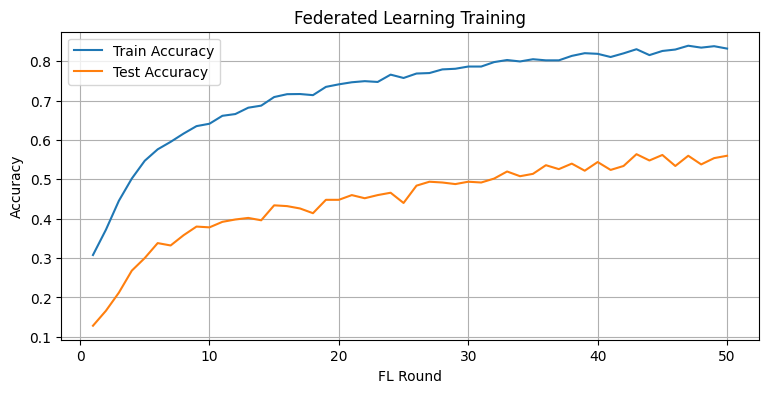

In [ ]:
#plot
plt.figure(figsize=(9, 4))
plt.plot(round_list, train_acc_list, label='Train Accuracy')
plt.plot(round_list, test_acc_list, label='Test Accuracy')
plt.xlabel('FL Round')
plt.ylabel('Accuracy')
plt.title('Federated Learning Training')
plt.legend()
plt.grid(True)
plt.show()

The model improves consistently over 50 rounds, reaching 0.83 train accuracy and 0.56 test accuracy. The gap between them is expected in this non-IID setting: the test set includes all 12 classes uniformly, while each client only has partial class coverage. No single client has seen all classes, so the global model must generalize from complementary local distributions — which is inherently harder than centralized training.

The plot show fast initial gains followed by gradual , and it's because of FedAvg on heterogeneous data. The slight oscillation in test accuracy during later rounds reflects the instability introduced by the non-IID distribution across clients.